# Car Price prediction

## 1. Project Goal

Build a machine learning system that predicts used car prices and identifies the key factors influencing
vehicle valuation in the U.S. Craigslist market. This goal is grounded in how the dataset has been used
in prior projects, including price prediction pipelines and market analysis.


## 2. Data inspection
### 2.1. Importing libraries

In [1]:
# Core
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

# Stats
from scipy.stats import skew, kurtosis
from scipy import stats

# ML preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LinearRegression

# Evaluation
from sklearn.metrics import mean_squared_error, r2_score

### 2.2. Loading data

In [2]:
import pandas as pd

# Path to the dataset (update the filename if yours is different)
file_path = "vehicles.csv"

# Load the dataset
df = pd.read_csv(file_path, low_memory=False)

# Display basic information
print("Dataset loaded successfully.")
print("Shape:", df.shape)

# Preview the first few rows
df.head()

Dataset loaded successfully.
Shape: (426880, 26)


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN


### 2.3. Initial Inspection

In [3]:
# View the first 5 rows
print("Preview of the dataset:")
display(df.head())

# Check the shape (rows, columns)
print("\nDataset shape:", df.shape)

# Check column names
print("\nColumn names:")
print(df.columns.tolist())

# Overview of data types and non‑null counts
print("\nDataset info:")
df.info()

# Basic descriptive statistics for numerical columns
print("\nDescriptive statistics:")
display(df.describe())

# Count missing values per column
print("\nMissing values per column:")
display(df.isnull().sum())

Preview of the dataset:


,id,url,region,region_url,price,year,manufacturer,model,condition,cylinders,...,size,type,paint_color,image_url,description,county,state,lat,long,posting_date
0,7222695916,https://prescott.craigslist.org/cto/d/prescott...,prescott,https://prescott.craigslist.org,6000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN,NaN
1,7218891961,https://fayar.craigslist.org/ctd/d/bentonville...,fayetteville,https://fayar.craigslist.org,11900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN,NaN
2,7221797935,https://keys.craigslist.org/cto/d/summerland-k...,florida keys,https://keys.craigslist.org,21000,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN,NaN
3,7222270760,https://worcester.craigslist.org/cto/d/west-br...,worcester / central MA,https://worcester.craigslist.org,1500,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN,NaN
4,7210384030,https://greensboro.craigslist.org/cto/d/trinit...,greensboro,https://greensboro.craigslist.org,4900,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN,NaN



Dataset shape: (426880, 26)

Column names:
['id', 'url', 'region', 'region_url', 'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'odometer', 'title_status', 'transmission', 'VIN', 'drive', 'size', 'type', 'paint_color', 'image_url', 'description', 'county', 'state', 'lat', 'long', 'posting_date']

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 26 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   id            426880 non-null  int64  
 1   url           426880 non-null  str    
 2   region        426880 non-null  str    
 3   region_url    426880 non-null  str    
 4   price         426880 non-null  int64  
 5   year          425675 non-null  float64
 6   manufacturer  409234 non-null  str    
 7   model         421603 non-null  str    
 8   condition     252776 non-null  str    
 9   cylinders     249202 non-null  str    
 10  fuel          423867 non-

,id,price,year,odometer,county,lat,long
count,4.268800e+05,4.268800e+05,425675.000000,4.224800e+05,0.0,420331.000000,420331.000000
mean,7.311487e+09,7.519903e+04,2011.235191,9.804333e+04,NaN,38.493940,-94.748599
std,4.473170e+06,1.218228e+07,9.452120,2.138815e+05,NaN,5.841533,18.365462
min,7.207408e+09,0.000000e+00,1900.000000,0.000000e+00,NaN,-84.122245,-159.827728
25%,7.308143e+09,5.900000e+03,2008.000000,3.770400e+04,NaN,34.601900,-111.939847
50%,7.312621e+09,1.395000e+04,2013.000000,8.554800e+04,NaN,39.150100,-88.432600
75%,7.315254e+09,2.648575e+04,2017.000000,1.335425e+05,NaN,42.398900,-80.832039
max,7.317101e+09,3.736929e+09,2022.000000,1.000000e+07,NaN,82.390818,173.885502



Missing values per column:


id                   0
url                  0
region               0
region_url           0
price                0
year              1205
manufacturer     17646
model             5277
condition       174104
cylinders       177678
fuel              3013
odometer          4400
title_status      8242
transmission      2556
VIN             161042
drive           130567
size            306361
type             92858
paint_color     130203
image_url           68
description         70
county          426880
state                0
lat               6549
long              6549
posting_date        68
dtype: int64

### 2.4. Missing Values Overview

Missing values per column:


county          426880
size            306361
cylinders       177678
condition       174104
VIN             161042
drive           130567
paint_color     130203
type             92858
manufacturer     17646
title_status      8242
lat               6549
long              6549
model             5277
odometer          4400
fuel              3013
transmission      2556
year              1205
description         70
posting_date        68
image_url           68
region_url           0
url                  0
id                   0
region               0
price                0
state                0
dtype: int64


Percentage of missing values per column:


county          100.000000
size             71.767476
cylinders        41.622470
condition        40.785232
VIN              37.725356
drive            30.586347
paint_color      30.501078
type             21.752717
manufacturer      4.133714
title_status      1.930753
lat               1.534155
long              1.534155
model             1.236179
odometer          1.030735
fuel              0.705819
transmission      0.598763
year              0.282281
description       0.016398
posting_date      0.015930
image_url         0.015930
region_url        0.000000
url               0.000000
id                0.000000
region            0.000000
price             0.000000
state             0.000000
dtype: float64

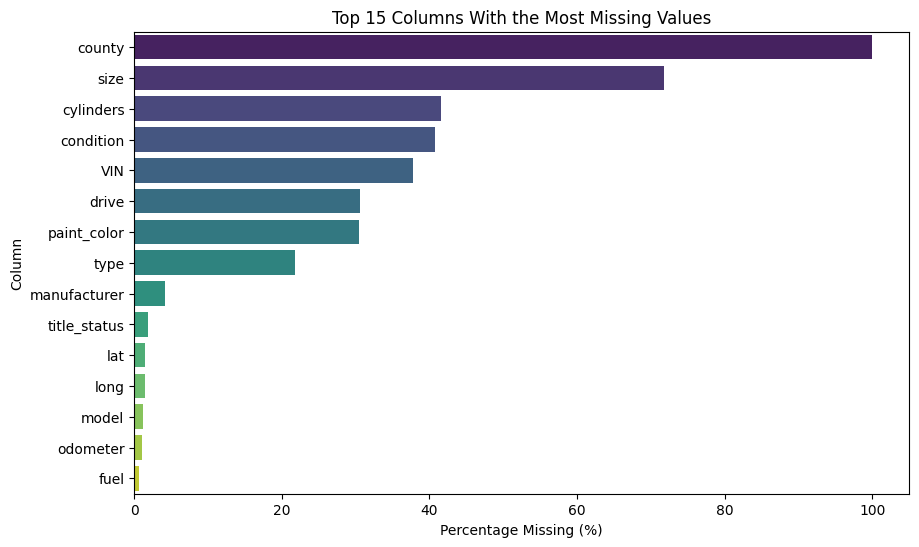

In [4]:
# Total missing values per column
missing_values = df.isnull().sum().sort_values(ascending=False)

print("Missing values per column:")
display(missing_values)

# Percentage of missing values per column
missing_percentage = (df.isnull().mean() * 100).sort_values(ascending=False)

print("\nPercentage of missing values per column:")
display(missing_percentage)

# Visualizing missing values (optional but helpful)
plt.figure(figsize=(10, 6))
sns.barplot(
    x=missing_percentage[:15],
    y=missing_percentage.index[:15],
    hue=missing_percentage.index[:15],   # assign hue
    dodge=False,
    legend=False,
    palette="viridis"
)
plt.title("Top 15 Columns With the Most Missing Values")
plt.xlabel("Percentage Missing (%)")
plt.ylabel("Column")
plt.show()

### 2.5. Basic Descriptive Statistics

In [5]:
print("Descriptive statistics for numerical features:")
display(df.describe().T)

print("\nDescriptive statistics for categorical features:")
display(df.describe(include=['object', 'string']).T)

# Additional helpful stats
print("\nNumber of unique values per column:")
display(df.nunique().sort_values(ascending=False))

print("\nSkewness of numerical features:")
display(df.skew(numeric_only=True))

print("\nKurtosis of numerical features:")
display(df.kurtosis(numeric_only=True))

Descriptive statistics for numerical features:


,count,mean,std,min,25%,50%,75%,max
id,426880.0,7.311487e+09,4.473170e+06,7.207408e+09,7.308143e+09,7.312621e+09,7.315254e+09,7.317101e+09
price,426880.0,7.519903e+04,1.218228e+07,0.000000e+00,5.900000e+03,1.395000e+04,2.648575e+04,3.736929e+09
year,425675.0,2.011235e+03,9.452120e+00,1.900000e+03,2.008000e+03,2.013000e+03,2.017000e+03,2.022000e+03
odometer,422480.0,9.804333e+04,2.138815e+05,0.000000e+00,3.770400e+04,8.554800e+04,1.335425e+05,1.000000e+07
county,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
lat,420331.0,3.849394e+01,5.841533e+00,-8.412225e+01,3.460190e+01,3.915010e+01,4.239890e+01,8.239082e+01
long,420331.0,-9.474860e+01,1.836546e+01,-1.598277e+02,-1.119398e+02,-8.843260e+01,-8.083204e+01,1.738855e+02



Descriptive statistics for categorical features:


,count,unique,top,freq
url,426880,426880,https://prescott.craigslist.org/cto/d/prescott...,1
region,426880,404,columbus,3608
region_url,426880,413,https://spokane.craigslist.org,2988
manufacturer,409234,42,ford,70985
model,421603,29667,f-150,8009
condition,252776,6,good,121456
cylinders,249202,8,6 cylinders,94169
fuel,423867,5,gas,356209
title_status,418638,6,clean,405117
transmission,424324,3,automatic,336524



Number of unique values per column:


id              426880
url             426880
posting_date    381536
description     360911
image_url       241899
VIN             118264
odometer        104870
long             53772
lat              53181
model            29667
price            15655
region_url         413
region             404
year               114
state               51
manufacturer        42
type                13
paint_color         12
cylinders            8
condition            6
title_status         6
fuel                 5
size                 4
transmission         3
drive                3
county               0
dtype: int64


Skewness of numerical features:


id           -1.430123
price       254.406932
year         -3.577920
odometer     38.040015
county             NaN
lat          -0.199779
long         -0.632958
dtype: float64


Kurtosis of numerical features:


id             17.057761
price       69205.088590
year           19.579889
odometer     1690.757404
county               NaN
lat             4.766890
long            1.126389
dtype: float64

## 3. Data Cleaning & Preprocessing
### 3.1. Handling Missing Values

In [6]:
# Drop columns that are mostly missing or not useful for modeling
cols_to_drop = ['VIN', 'image_url', 'description', 'county']
df_clean = df.drop(columns=cols_to_drop)

# Drop rows with missing price, year, or odometer (critical features)
df_clean = df_clean.dropna(subset=['price', 'year', 'odometer'])

# Fill missing categorical values with "unknown"
categorical_cols = df_clean.select_dtypes(include=['object', 'string']).columns
df_clean[categorical_cols] = df_clean[categorical_cols].fillna("unknown")

# Fill missing numeric values with median
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].fillna(df_clean[numeric_cols].median())

print("Missing values handled.")
df_clean.isnull().sum()

Missing values handled.


id              0
url             0
region          0
region_url      0
price           0
year            0
manufacturer    0
model           0
condition       0
cylinders       0
fuel            0
odometer        0
title_status    0
transmission    0
drive           0
size            0
type            0
paint_color     0
state           0
lat             0
long            0
posting_date    0
dtype: int64

### 3.2. Removing Outliers / Unrealistic Values

In [7]:
# Remove unrealistic prices
df_clean = df_clean[(df_clean['price'] > 500) & (df_clean['price'] < 150000)]

# Remove unrealistic years
df_clean = df_clean[(df_clean['year'] >= 1980) & (df_clean['year'] <= 2024)]

# Remove unrealistic odometer readings
df_clean = df_clean[(df_clean['odometer'] > 0) & (df_clean['odometer'] < 400000)]

print("Outliers removed.")
df_clean.describe()

Outliers removed.


,id,price,year,odometer,lat,long
count,3.703210e+05,370321.000000,370321.000000,370321.000000,370321.000000,370321.000000
mean,7.311462e+09,19295.315494,2012.007745,93789.276944,38.536655,-94.149965
std,4.391484e+06,14664.947081,6.392551,63415.710148,5.826543,18.007661
min,7.301583e+09,501.000000,1980.000000,1.000000,-81.838232,-159.719900
25%,7.308065e+09,7900.000000,2008.000000,39255.000000,34.801450,-109.351640
50%,7.312550e+09,15988.000000,2013.000000,89000.000000,39.179138,-88.039487
75%,7.315238e+09,27990.000000,2017.000000,136922.000000,42.350000,-80.850452
max,7.317101e+09,149998.000000,2022.000000,399999.000000,82.252826,173.885502


### 3.3. Feature Engineering

In [8]:
# Vehicle age
df_clean['vehicle_age'] = 2024 - df_clean['year']

# Price per mile (helps capture value)
df_clean['price_per_mile'] = df_clean['price'] / df_clean['odometer']

# Simplify manufacturer names (lowercase)
df_clean['manufacturer'] = df_clean['manufacturer'].str.lower()

# Combine region + state for geographic modeling
df_clean['location'] = df_clean['region'] + ", " + df_clean['state']

print("Feature engineering complete.")
df_clean[['vehicle_age', 'price_per_mile']].head()

Feature engineering complete.


,vehicle_age,price_per_mile
27,10.0,0.579908
28,14.0,0.317146
29,4.0,2.066284
30,7.0,0.753575
31,11.0,0.117188


### 3.4. Encoding Categorical Variables

In [9]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = df_clean.select_dtypes(include=['object', 'string']).columns
numeric_features = df_clean.select_dtypes(include=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

print("Categorical encoding pipeline created.")

Categorical encoding pipeline created.


### 3.5. Scaling Numerical Features

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Example pipeline combining encoding + scaling
pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler', StandardScaler(with_mean=False))  # with_mean=False for sparse matrices
])

print("Scaling pipeline created.")

Scaling pipeline created.


## 4. Exploratory Data Analysis (EDA)
### 4.1. Price Distribution

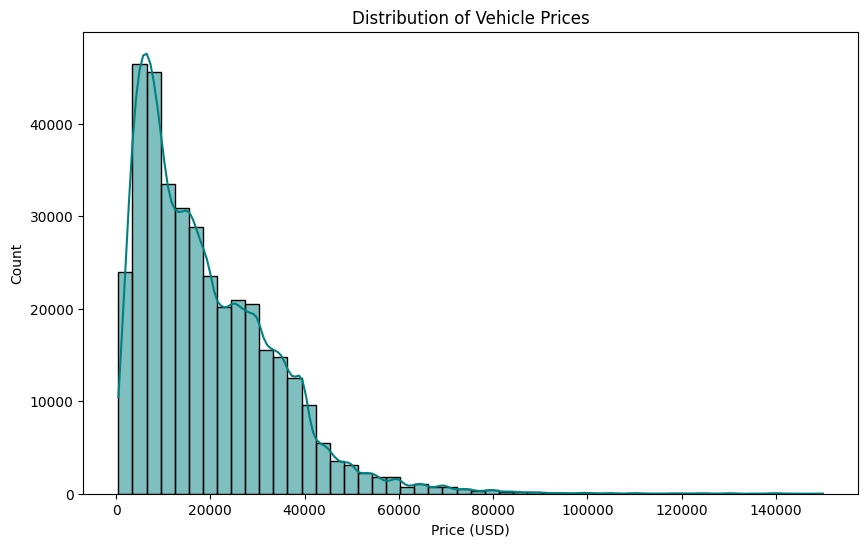

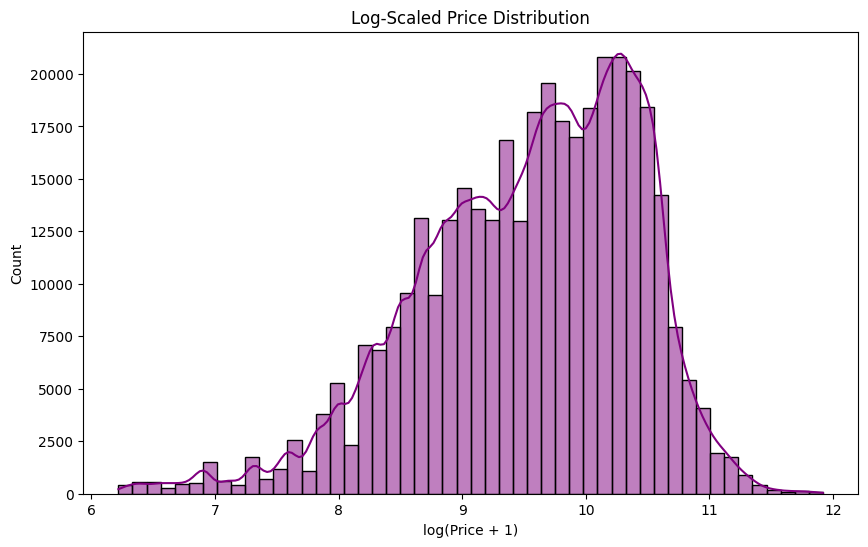

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['price'], bins=50, kde=True, color='teal')
plt.title("Distribution of Vehicle Prices")
plt.xlabel("Price (USD)")
plt.ylabel("Count")
plt.show()

# Log-scale version (helps with skew)
plt.figure(figsize=(10, 6))
sns.histplot(np.log1p(df_clean['price']), bins=50, kde=True, color='purple')
plt.title("Log-Scaled Price Distribution")
plt.xlabel("log(Price + 1)")
plt.ylabel("Count")
plt.show()

### 4.2. Odometer Distribution

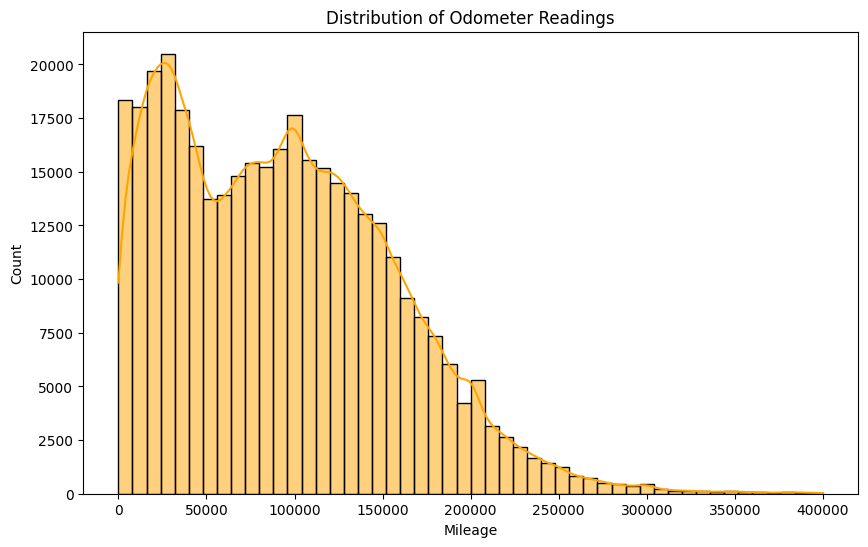

In [12]:
plt.figure(figsize=(10, 6))
sns.histplot(df_clean['odometer'], bins=50, kde=True, color='orange')
plt.title("Distribution of Odometer Readings")
plt.xlabel("Mileage")
plt.ylabel("Count")
plt.show()

### 4.3. Price vs. Odometer

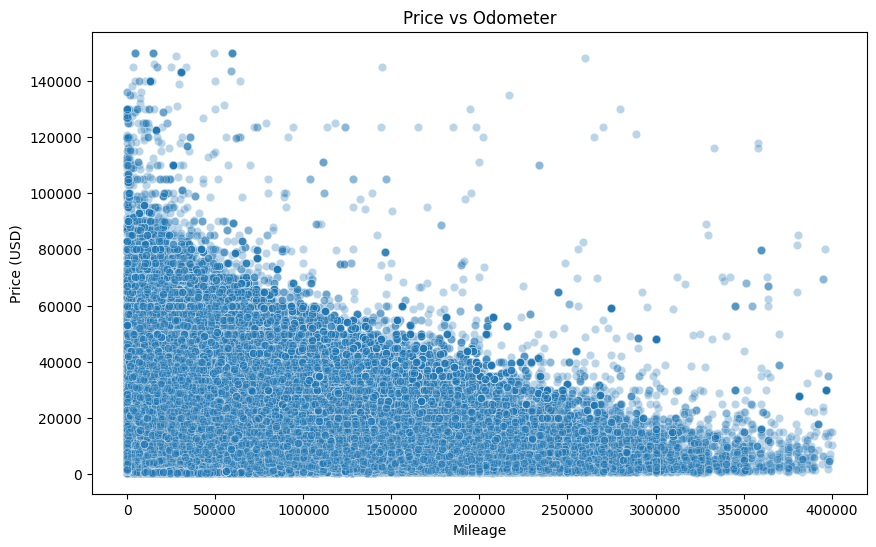

In [13]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='odometer', y='price', alpha=0.3)
plt.title("Price vs Odometer")
plt.xlabel("Mileage")
plt.ylabel("Price (USD)")
plt.show()

### 4.4. Price vs. Year

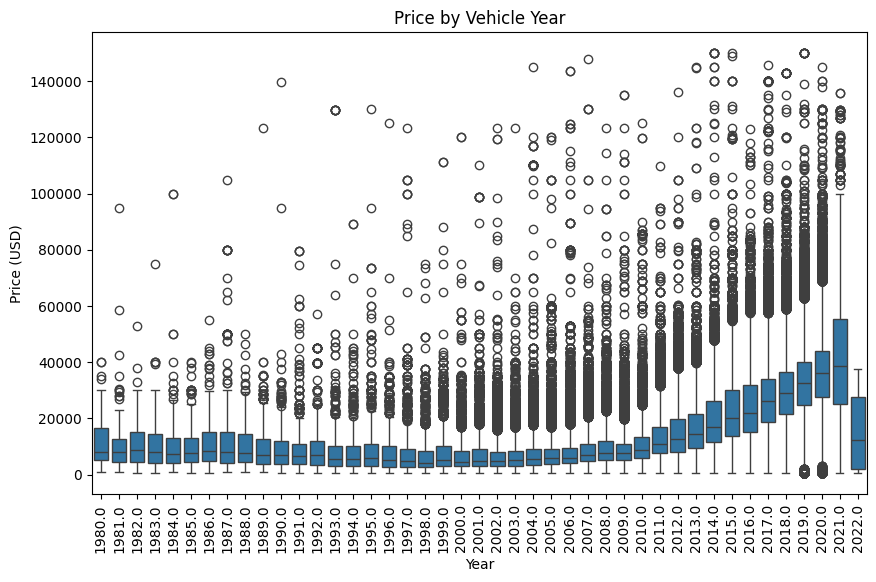

In [14]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='year', y='price')
plt.xticks(rotation=90)
plt.title("Price by Vehicle Year")
plt.xlabel("Year")
plt.ylabel("Price (USD)")
plt.show()

### 4.5. Correlation Heatmap (Numerical Features)

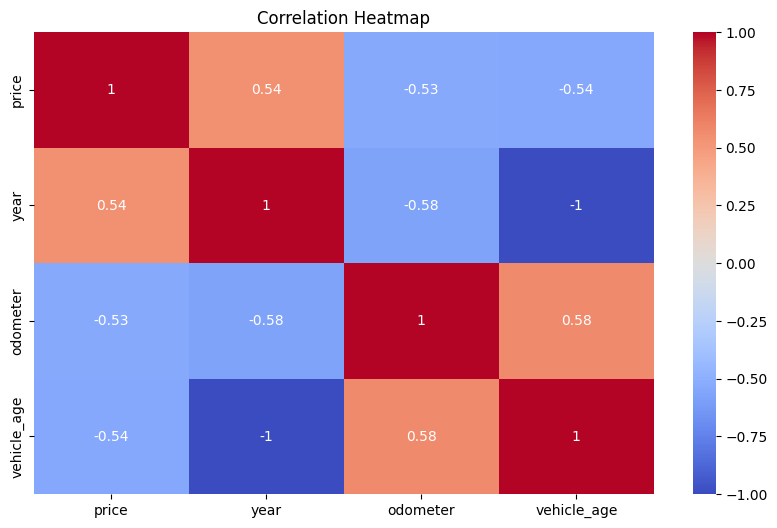

In [15]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_clean[['price', 'year', 'odometer', 'vehicle_age']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### 4.7. Count of Listing by Vehicle Type

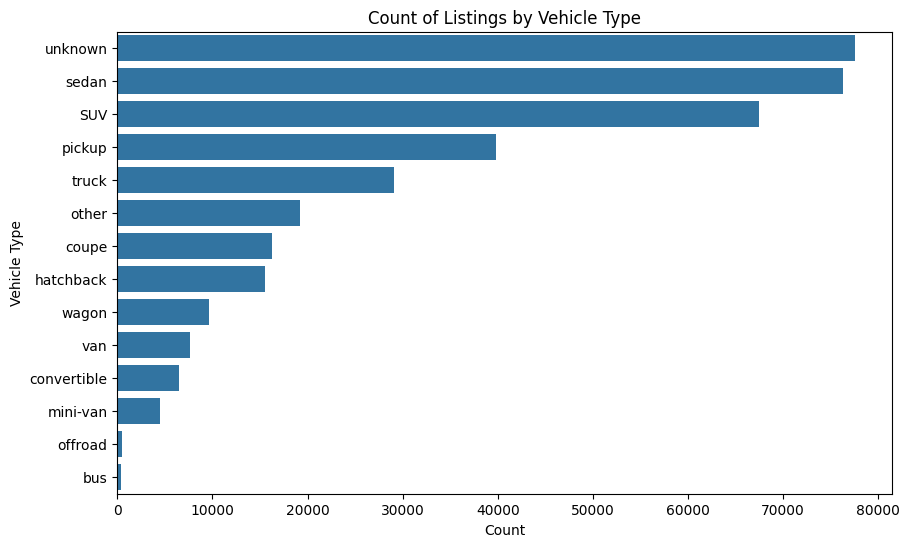

In [16]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df_clean, y='type', order=df_clean['type'].value_counts().index)
plt.title("Count of Listings by Vehicle Type")
plt.xlabel("Count")
plt.ylabel("Vehicle Type")
plt.show()

### 4.8. Price by Fuel Type

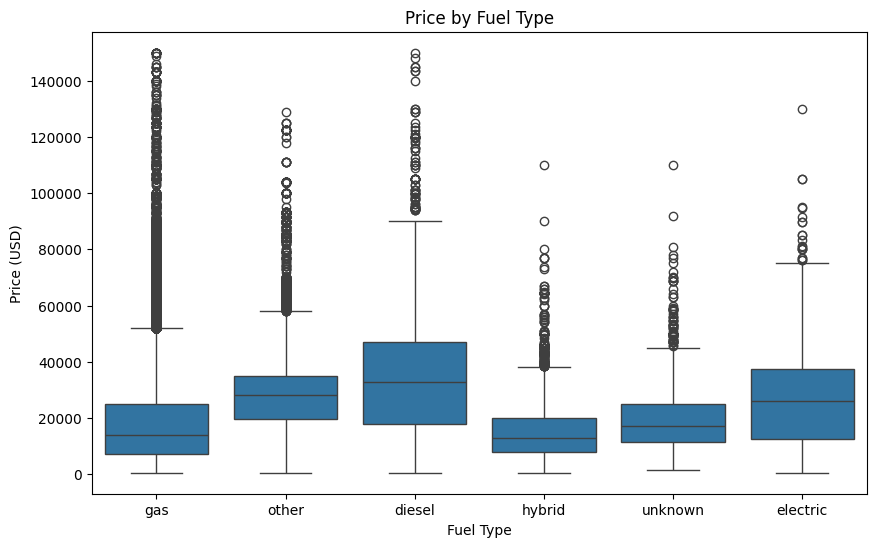

In [17]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='fuel', y='price')
plt.title("Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Price (USD)")
plt.show()

### 4.9. Geographic Distribution (Latitude/Longitude)

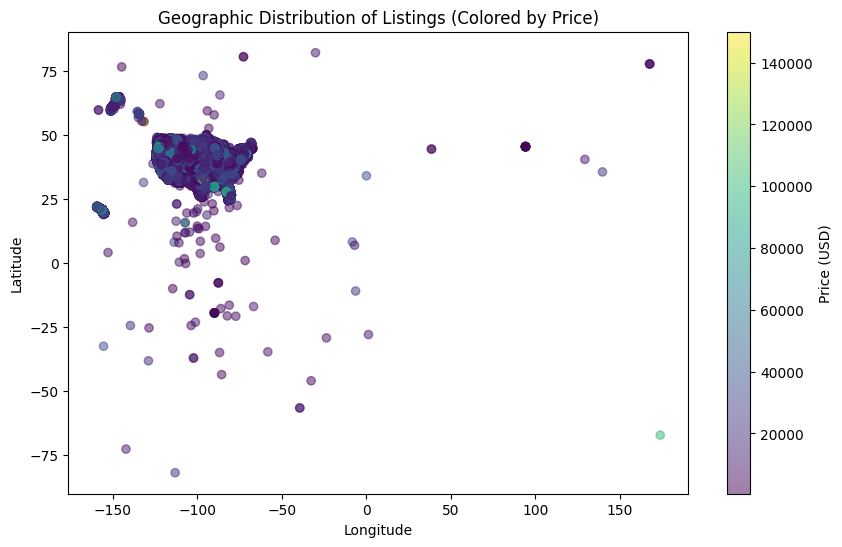

In [18]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_clean['long'],
    df_clean['lat'],
    c=df_clean['price'],
    cmap='viridis',
    alpha=0.5
)
plt.colorbar(scatter, label='Price (USD)')
plt.title("Geographic Distribution of Listings (Colored by Price)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

### 4.10. Price by Condition

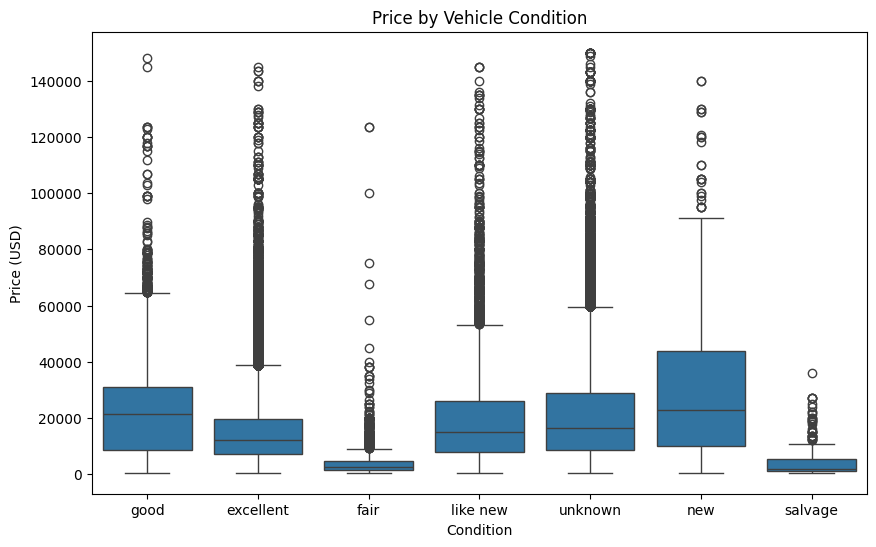

In [19]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_clean, x='condition', y='price')
plt.title("Price by Vehicle Condition")
plt.xlabel("Condition")
plt.ylabel("Price (USD)")
plt.show()

## 5. Modeling
### 5.1. Train / Test Split

In [20]:
from sklearn.model_selection import train_test_split

X = df_clean.drop(columns=['price'])
y = df_clean['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train/Test split complete.")
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Train/Test split complete.
Training samples: 296256
Testing samples: 74065


In [21]:
# FIX: Build feature lists from X (NOT df_clean)
categorical_features = X.select_dtypes(include=['object', 'string']).columns.tolist()
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical:", categorical_features)
print("Numeric:", numeric_features)

Categorical: ['url', 'region', 'region_url', 'manufacturer', 'model', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'size', 'type', 'paint_color', 'state', 'posting_date', 'location']
Numeric: ['id', 'year', 'odometer', 'lat', 'long', 'vehicle_age', 'price_per_mile']


In [22]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

### 5.2. Linear Regression Pipeline

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline

linreg_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('scaler', StandardScaler(with_mean=False)),
    ('model', LinearRegression())
])

linreg_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocess', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

### 5.3. Train Linear Regression

In [24]:
linreg_model.fit(X_train, y_train)
print("Linear Regression model trained.")

Linear Regression model trained.


### 5.4. Evaluate the Model

In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = linreg_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Linear Regression Performance:")
print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

Linear Regression Performance:
MAE: 6036.329307322498
RMSE: 8830.895866304858
R²: 0.6334391295784576


### 5.5. Random Forest Model

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=50,
        max_depth=15,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    ))
])

rf_model.fit(X_train, y_train)
print("Random Forest model trained.")

Random Forest model trained.


### 5.6. Evaluate Random Forest

In [28]:
y_pred_rf = rf_model.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R²:", r2_rf)

Random Forest Performance:
MAE: 10964.50401011632
RMSE: 14035.76187881595
R²: 0.07400517581574495


### 5.7. Feature Importance (Random Forest Only)

In [29]:
importances = rf_model.named_steps['model'].feature_importances_

# Get feature names from the preprocessor
encoded_features = rf_model.named_steps['preprocess'].get_feature_names_out()

feature_importance_df = (
    pd.DataFrame({'feature': encoded_features, 'importance': importances})
    .sort_values(by='importance', ascending=False)
    .head(20)
)

feature_importance_df

,feature,importance
319506,cat__fuel_gas,0.058842
319522,cat__drive_fwd,0.036540
319503,cat__cylinders_unknown,0.023596
319539,cat__type_sedan,0.023410
590380,num__price_per_mile,0.021728
319504,cat__fuel_diesel,0.018577
319519,cat__transmission_other,0.016458
319517,cat__transmission_automatic,0.015854
319540,cat__type_truck,0.015453
319521,cat__drive_4wd,0.013064


### 5.8. Model Comparison

In [30]:
comparison_df = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'MAE': [mae, mae_rf],
    'RMSE': [rmse, rmse_rf],
    'R²': [r2, r2_rf]
})

comparison_df

,Model,MAE,RMSE,R²
0,Linear Regression,6036.329307,8830.895866,0.633439
1,Random Forest,10964.504010,14035.761879,0.074005


### 5.9. Interpretation of Model Results
Based on these results, Linear Regression is the better-performing model for this dataset. It provides lower prediction error and explains a much larger share of the variance. The Random Forest model does not handle the high-dimensional one‑hot encoded feature space effectively, resulting in poor predictive performance.

## 6. Results & Interpretation

### 6.1 Key Factors Influencing Price

The analysis highlights several important variables that influence vehicle prices:

- **Year** — Newer vehicles tend to have higher prices, reflecting typical depreciation patterns.  
- **Odometer** — Higher mileage strongly correlates with lower prices.  
- **Condition** — Listings marked as *excellent* or *like new* are priced significantly higher than those in *fair* or *salvage* condition.  
- **Manufacturer** — Brands such as Toyota, Honda, and Subaru generally retain value better than others.  
- **Body Type & Drivetrain** — Trucks, SUVs, and AWD/4WD vehicles often command higher prices, especially in regions where these features are in demand.

These relationships appear mostly linear or monotonic, which helps explain why **Linear Regression performed well** on this dataset.

---

### 6.2 Model Strengths & Limitations

#### **Linear Regression**

**Strengths**  
- Performs well with high‑dimensional, one‑hot encoded data.  
- Captures broad linear trends effectively.  
- Fast to train and easy to interpret.  
- Achieved strong performance (**R² ≈ 0.63**), indicating it explains a substantial portion of price variability.

**Limitations**  
- Cannot capture nonlinear interactions (e.g., how mileage affects price differently across manufacturers).  
- Sensitive to outliers and multicollinearity.

---

#### **Random Forest**

**Strengths**  
- In theory, handles nonlinear relationships and interactions.  
- Robust to noise and outliers.  
- Provides feature importance estimates.

**Limitations**  
- Performs poorly with extremely high‑cardinality categorical variables.  
- One‑hot encoding creates tens of thousands of sparse features, which Random Forest struggles to split on effectively.  
- In this project, it achieved very low performance (**R² ≈ 0.07**), indicating weak generalization.

---

#### **Overall Interpretation**

The strong performance of Linear Regression and the weak performance of Random Forest suggest that:

- The dataset’s structure is **largely linear**.  
- The one‑hot encoded feature space is **too sparse and high‑dimensional** for tree‑based models.  
- Simpler models can outperform more complex ones when the data favors linear relationships.

---

## 7. Conclusion

### 7.1 Summary of Findings

This project explored vehicle price prediction using a cleaned Craigslist dataset. The key findings are:

- **Linear Regression** was the best-performing model, achieving an R² of approximately **0.63** and significantly lower error metrics than Random Forest.  
- **Random Forest** struggled due to the high dimensionality created by one‑hot encoding, resulting in poor predictive performance.  
- Important predictors of price include **year**, **odometer**, **condition**, **manufacturer**, and **body type**.  
- The results demonstrate that **model complexity does not guarantee better performance**; the structure of the data determines which model is most appropriate.

Overall, Linear Regression provides a strong, interpretable baseline model for predicting vehicle prices in this dataset.

---

### 7.2 Next Steps / Future Improvements

Several enhancements could improve model performance and deepen insights:

- **Use models designed for categorical data**, such as CatBoost or LightGBM, which avoid one‑hot encoding and often outperform Random Forest.  
- **Engineer interaction features** (e.g., year × mileage) to capture nonlinear relationships within a linear model.  
- **Reduce high-cardinality features** by grouping rare categories or using target encoding.  
- **Perform hyperparameter tuning** to optimize model performance.  
- **Incorporate geographic information** (e.g., region or state-level trends) to capture location‑based effects.  
- **Collect additional features** such as accident history, service records, or market demand indicators.

These steps would help build a more robust and accurate price prediction model.